In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

Load Dataset

In [14]:
df = pd.read_parquet("dataset.parquet")

print(df.shape)

(564, 334)


Select important raw signals

In [15]:
selected_signals = [
    "DXP_Inj1PrsAct",
    "DXP_Inj1VelAct",
    "DXP_Inj1PosAct",
    "DXP_MldCavPrs1Act"
]

Select labels

In [16]:
label_cols = [
    "LBL_SinkMarks",
    "LBL_SprueCircle",
    "LBL_StreaksLevel1",
    "LBL_StreaksLevel2",
    "LBL_Underfilled",
    "LBL_OldGranulate"
]

label_cols = [c for c in label_cols if c in df.columns]

y = df[label_cols].fillna(0).values

print(y.shape)
print(label_cols)

(564, 6)
['LBL_SinkMarks', 'LBL_SprueCircle', 'LBL_StreaksLevel1', 'LBL_StreaksLevel2', 'LBL_Underfilled', 'LBL_OldGranulate']


Resample signals to fixed length

In [17]:
def resample_signal(signal, target_len=500):
    signal = np.array(signal, dtype=float)
    old_index = np.linspace(0, 1, len(signal))
    new_index = np.linspace(0, 1, target_len)
    return np.interp(new_index, old_index, signal)

Prepare Input Tensor

In [18]:
target_len = 500

X_list = []

for _, row in df.iterrows():
    cycle_signals = []

    for signal in selected_signals:
        resampled = resample_signal(row[signal], target_len)
        cycle_signals.append(resampled)

    cycle_signals = np.stack(cycle_signals, axis=1)
    X_list.append(cycle_signals)

X = np.array(X_list)

print(X.shape)

(564, 500, 4)


Train-test split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (451, 500, 4)
X_test: (113, 500, 4)
y_train: (451, 6)
y_test: (113, 6)


## Data Normalization

The training and testing datasets are standardized using `StandardScaler`.  
The time-series data are reshaped to two dimensions for scaling and then reshaped back to their original three-dimensional format. This ensures that all input features are on a similar scale before training the TCN model.

In [20]:
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

X_train = X_train_scaled.reshape(X_train.shape)
X_test = X_test_scaled.reshape(X_test.shape)

print(X_train.shape)
print(X_test.shape)

(451, 500, 4)
(113, 500, 4)


Build TCN-Inspired Model

In [21]:
model = models.Sequential([
    layers.Input(shape=(target_len, len(selected_signals))),

    layers.Conv1D(64, kernel_size=5, padding="causal", dilation_rate=1, activation="relu"),
    layers.BatchNormalization(),

    layers.Conv1D(64, kernel_size=5, padding="causal", dilation_rate=2, activation="relu"),
    layers.BatchNormalization(),

    layers.Conv1D(64, kernel_size=5, padding="causal", dilation_rate=4, activation="relu"),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling1D(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(len(label_cols), activation="sigmoid")
])


model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 500, 64)        │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 500, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 500, 64)        │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 500, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,750 (186.52 KB)

 Trainable params: 47,366 (185.02 KB)

 Non-trainable params: 384 (1.50 KB)

## Train the TCN-Inspired Model

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - binary_accuracy: 0.7870 - loss: 0.5218 - precision: 0.2210 - recall: 0.4927 - val_binary_accuracy: 0.9084 - val_loss: 0.5816 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - binary_accuracy: 0.8843 - loss: 0.3505 - precision: 0.3846 - recall: 0.3659 - val_binary_accuracy: 0.9084 - val_loss: 0.5001 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - binary_accuracy: 0.8986 - loss: 0.2690 - precision: 0.4435 - recall: 0.2683 - val_binary_accuracy: 0.9084 - val_loss: 0.4138 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - binary_accuracy: 0.9181 - loss: 0.2217 - precision: 0.6273 - recall: 0.3366 - val_binary_accuracy: 0.9084 - val_loss: 0.3470 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - binary_accuracy: 0.9227

## Training Loss Visualization

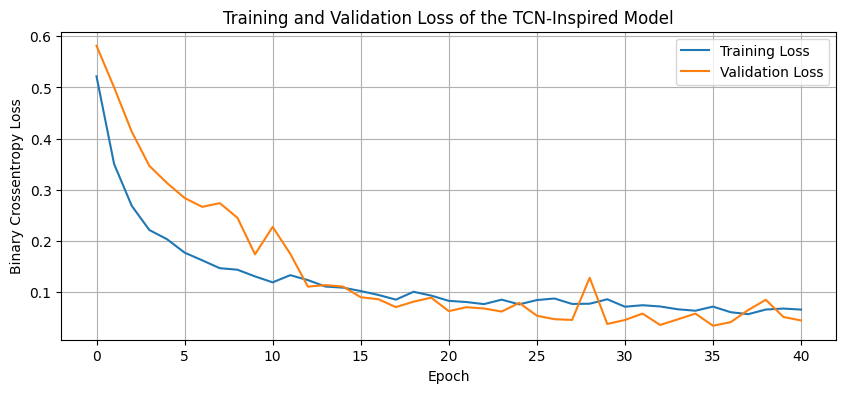

In [23]:
plt.figure(figsize=(10,4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("Training and Validation Loss of the TCN-Inspired Model")
plt.legend()
plt.grid(True)
plt.show()

## Model Evaluation Metrics


In [24]:
# Threshold 0.5 is used as the baseline decision threshold
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_cols,
    zero_division=0
))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
                   precision    recall  f1-score   support

    LBL_SinkMarks       1.00      1.00      1.00        36
  LBL_SprueCircle       1.00      0.94      0.97        17
LBL_StreaksLevel1       1.00      0.88      0.93         8
LBL_StreaksLevel2       0.67      1.00      0.80         2
  LBL_Underfilled       1.00      0.58      0.74        12
 LBL_OldGranulate       0.00      0.00      0.00         2

        micro avg       0.99      0.88      0.93        77
        macro avg       0.78      0.73      0.74        77
     weighted avg       0.97      0.88      0.91        77
      samples avg       0.50      0.49      0.49        77



## Model Evaluation

The TCN-inspired model was evaluated on the test dataset using precision, recall, and F1-score for each defect class.

The model achieved excellent performance for the major defect classes. It obtained an F1-score of **1.00** for **LBL_SinkMarks**, **0.97** for **LBL_SprueCircle**, **0.93** for **LBL_StreaksLevel1**, **0.80** for **LBL_StreaksLevel2**, and **0.74** for **LBL_Underfilled**. These results indicate that the model effectively learned temporal patterns from the selected manufacturing sensor signals.

The rare defect class **LBL_OldGranulate** was not detected because only two positive samples were present in the test set. This highlights the impact of severe class imbalance on model performance.

Overall, the model achieved a **micro-average F1-score of 0.93**, **macro-average F1-score of 0.74**, and **weighted-average F1-score of 0.91**. The high micro and weighted F1-scores demonstrate strong overall performance, while the lower macro F1-score reflects the difficulty of predicting extremely rare defect classes.

## Conclusion

A TCN-inspired deep learning model was developed to classify multiple manufacturing defects using raw time-series sensor data. The model successfully learned temporal patterns from four key DXP sensor signals after resampling and normalization.

The results demonstrate strong performance for the major defect classes, while prediction of rare defects remains challenging because of the highly imbalanced dataset. Overall, the proposed TCN-inspired model provides an effective deep learning baseline for industrial time-series defect classification and serves as a useful comparison with traditional machine learning approaches such as XGBoost.

## Model Comparison

| Model | Input Data | Strength |
|------|------------|----------|
| Random Forest / XGBoost | Engineered tabular features | Explainable and robust for small datasets |
| TCN-inspired model | Raw DXP time-series signals | Learns temporal patterns directly |

The TCN model is used as a deep learning comparison model, while the tree-based model is used as the main explainable baseline.

## Future Work

The current TCN-inspired model was evaluated using a single train-test split. In future work, GroupKFold cross-validation based on experiment groups can be used to provide a more robust evaluation and reduce the possibility of experiment-level data leakage.

Additional improvements may include incorporating more sensor signals, addressing class imbalance using advanced sampling techniques, and optimizing the TCN architecture through hyperparameter tuning.